In [1]:
!unzip "archive (4).zip"

Archive:  archive (4).zip
  inflating: datasets/apps.csv       
  inflating: datasets/user_reviews.csv  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main apps dataset from inside the datasets folder
df = pd.read_csv('datasets/apps.csv')

# View the first 5 rows and data types
print("Dataset Summary:")
print(df.info())
df.head()

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
None


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# 1. Clean the 'Installs' column
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].astype(int)

# 2. Clean the 'Price' column
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = df['Price'].astype(float)

# 3. Verify the changes
print(df[['Installs', 'Price']].dtypes)
df[['Installs', 'Price']].head()

Installs      int64
Price       float64
dtype: object


,Installs,Price
0,10000,0.0
1,500000,0.0
2,5000000,0.0
3,50000000,0.0
4,100000,0.0


/tmp/ipykernel_2481/3870813431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


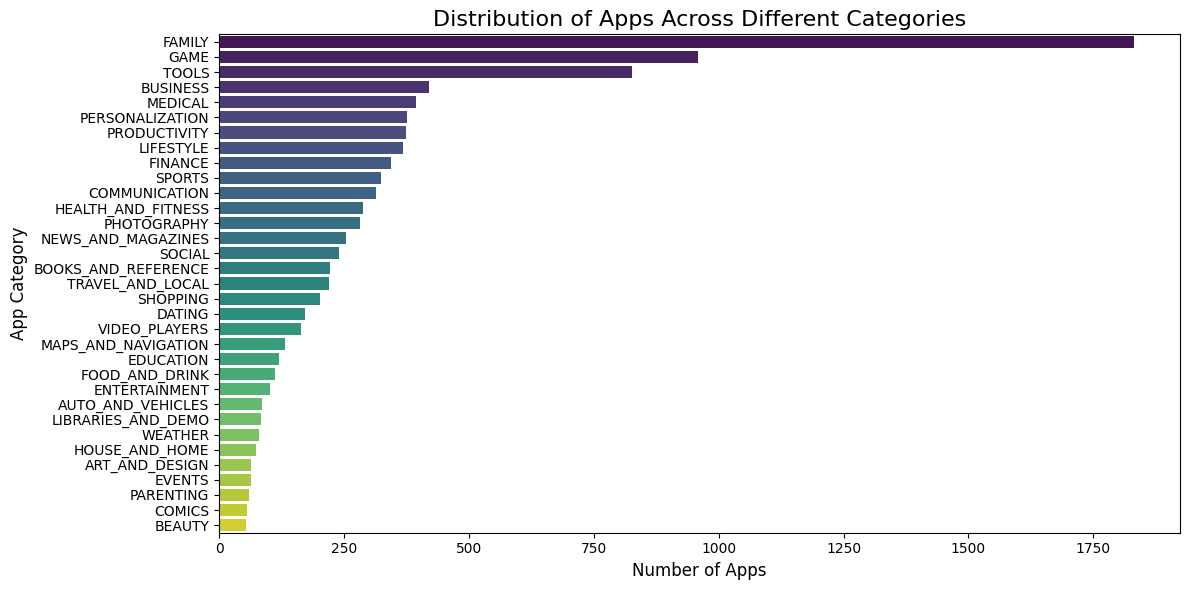

In [4]:
# Count the number of apps in each category
category_counts = df['Category'].value_counts()

# Set up the visualization plot style and size
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')

# Add titles and axis labels
plt.title('Distribution of Apps Across Different Categories', fontsize=16)
plt.xlabel('Number of Apps', fontsize=12)
plt.ylabel('App Category', fontsize=12)

# Show the chart clearly
plt.tight_layout()
plt.show()

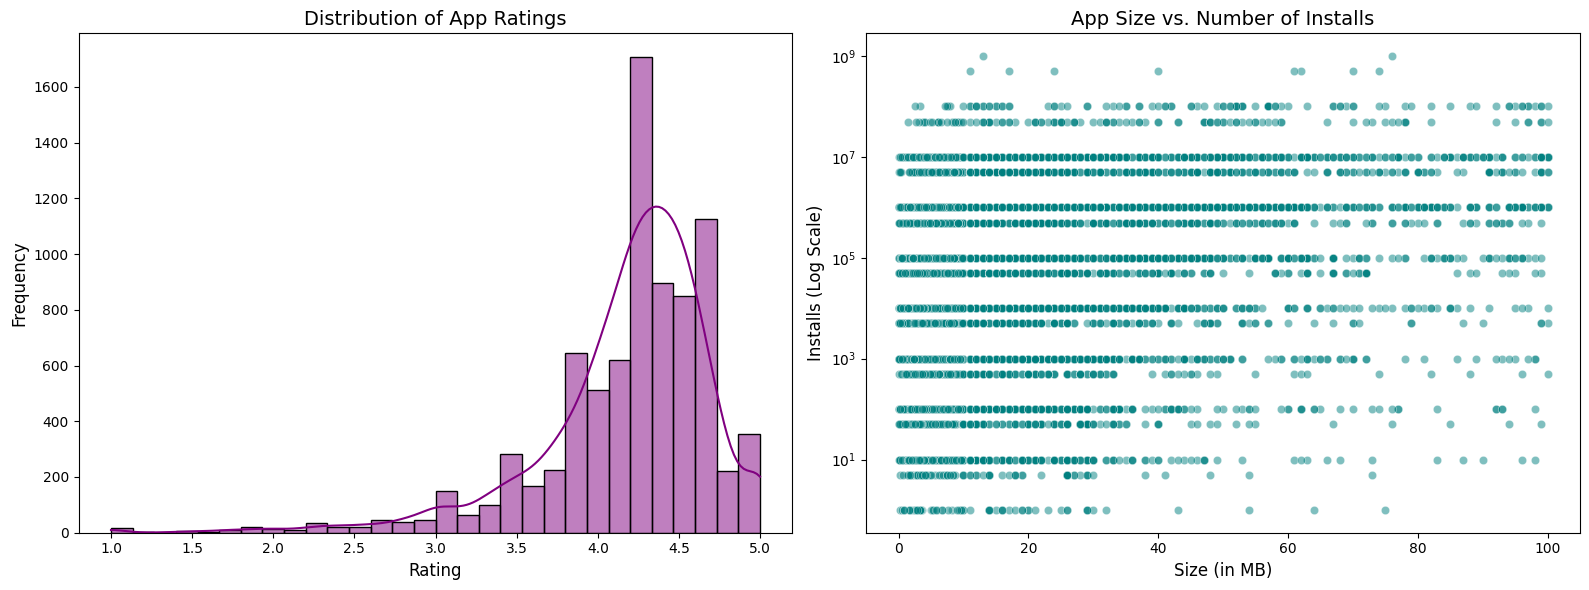

In [5]:
# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot the Distribution of App Ratings
sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribution of App Ratings', fontsize=14)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Plot Size vs. Popularity (Installs) using a scatter plot
# Dropping rows where Size might be null just for this visualization
size_df = df.dropna(subset=['Size'])
sns.scatterplot(data=size_df, x='Size', y='Installs', alpha=0.5, color='teal', ax=axes[1])
axes[1].set_yscale('log') # Using log scale since install numbers span from 0 to 1 Billion+
axes[1].set_title('App Size vs. Number of Installs', fontsize=14)
axes[1].set_xlabel('Size (in MB)', fontsize=12)
axes[1].set_ylabel('Installs (Log Scale)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2481/3313159378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Rating', palette='Set2', ax=axes[1])


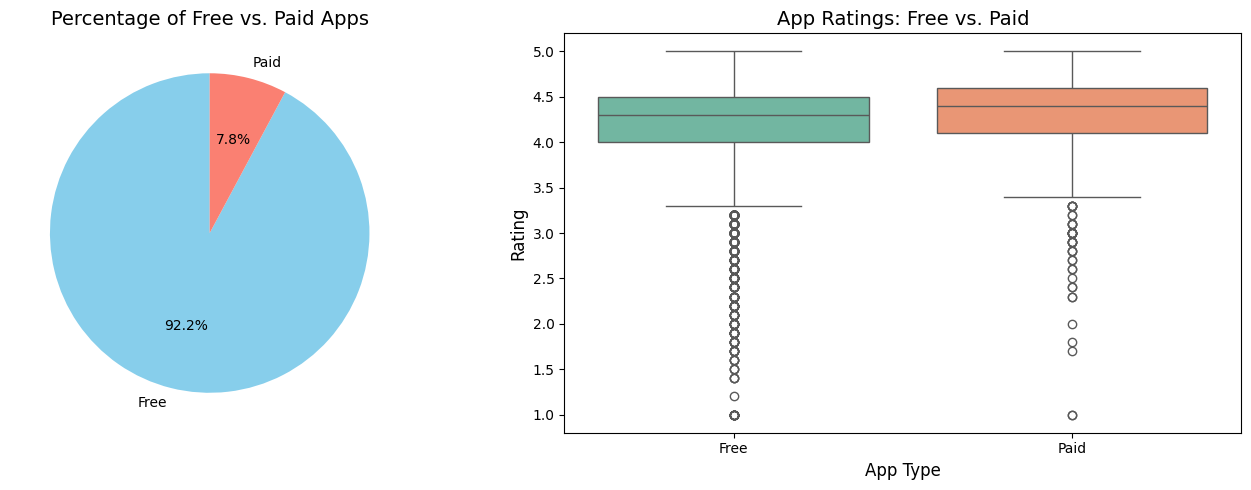

In [6]:
# Set up another side-by-side plotting area for pricing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie chart showing Free vs Paid distribution
type_counts = df['Type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
axes[0].set_title('Percentage of Free vs. Paid Apps', fontsize=14)

# 2. Boxplot comparing Ratings of Free vs Paid apps
sns.boxplot(data=df, x='Type', y='Rating', palette='Set2', ax=axes[1])
axes[1].set_title('App Ratings: Free vs. Paid', fontsize=14)
axes[1].set_xlabel('App Type', fontsize=12)
axes[1].set_ylabel('Rating', fontsize=12)

plt.tight_layout()
plt.show()

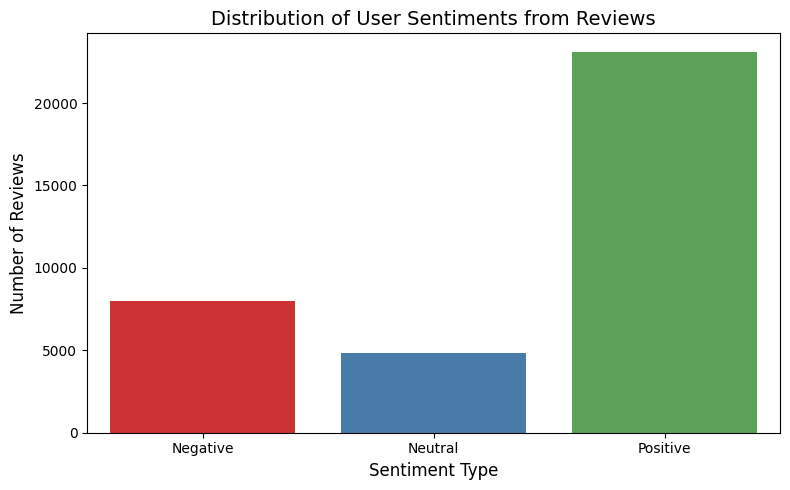

In [7]:
# 1. Load the user reviews dataset
reviews_df = pd.read_csv('datasets/user_reviews.csv')

# 2. Merge the datasets on the 'App' column
merged_df = pd.merge(df, reviews_df, on='App')

# 3. Drop rows where Sentiment is missing so our graph is clean
merged_df = merged_df.dropna(subset=['Sentiment'])

# 4. Create a plot to visualize the distribution of user sentiments
plt.figure(figsize=(8, 5))
sns.countplot(data=merged_df, x='Sentiment', palette='Set1', hue='Sentiment', legend=False)

# Add title and labels
plt.title('Distribution of User Sentiments from Reviews', fontsize=14)
plt.xlabel('Sentiment Type', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2481/566018999.py:19: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


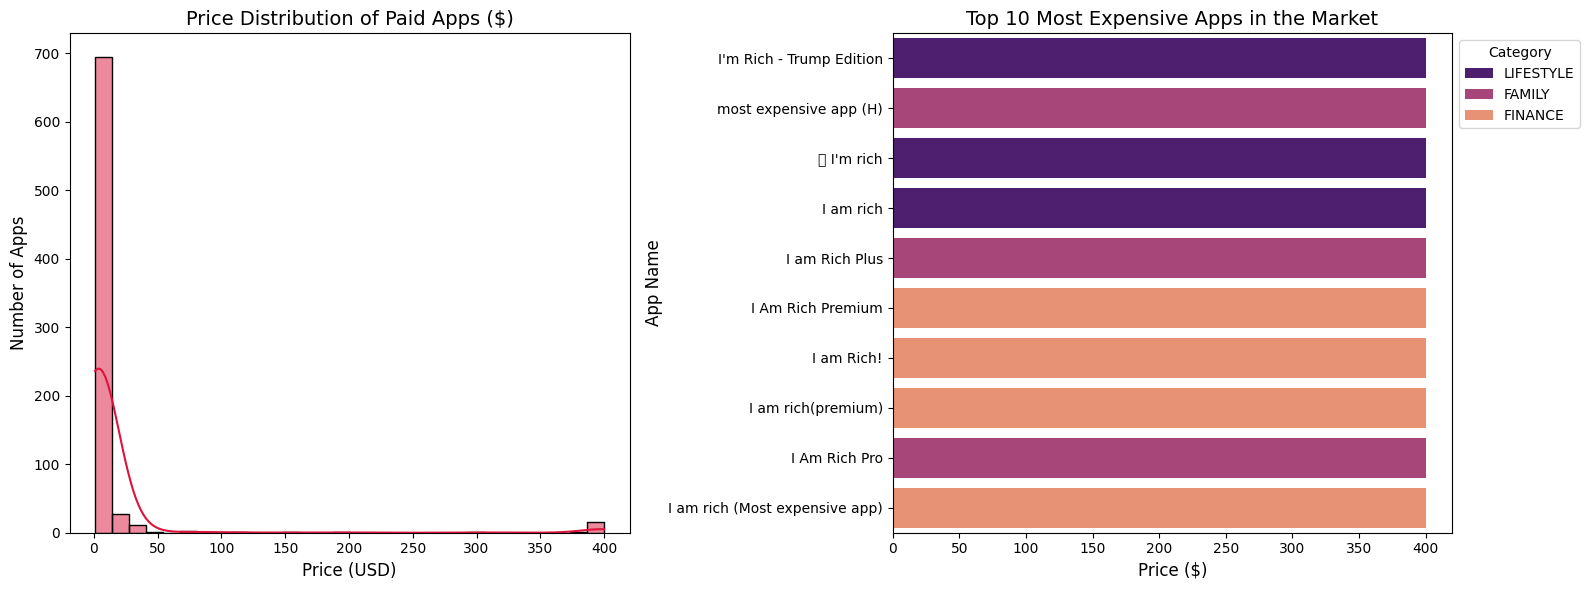

In [8]:
# Create a comprehensive final breakdown subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution of Paid App Prices (excluding free apps)
paid_apps = df[df['Price'] > 0]
sns.histplot(paid_apps['Price'], bins=30, kde=True, color='crimson', ax=axes[0])
axes[0].set_title('Price Distribution of Paid Apps ($)', fontsize=14)
axes[0].set_xlabel('Price (USD)', fontsize=12)
axes[0].set_ylabel('Number of Apps', fontsize=12)

# 2. Top 10 Most Expensive Apps and their Categories
top_expensive = paid_apps.nlargest(10, 'Price')
sns.barplot(data=top_expensive, x='Price', y='App', hue='Category', dodge=False, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Most Expensive Apps in the Market', fontsize=14)
axes[1].set_xlabel('Price ($)', fontsize=12)
axes[1].set_ylabel('App Name', fontsize=12)
axes[1].get_legend().set_bbox_to_anchor((1, 1)) # Move legend outside the plot box

plt.tight_layout()
plt.show()